In [43]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import csv
import pandas as pd
import re
import seaborn as sns

> The History.csv file was dowload from wikipedia using a query from https://www.reddit.com/r/datasets/comments/cho4lq/request_a_dataset_containing_the_dates_of_major/ and the modified for our pourpose

#defaultView:Timeline
select ?event ?date ?label ?image {
  ?event wdt:P31/wdt:P279* wd:Q1190554 .  # something that is a subtype of occurence
  ?event wdt:P585 ?date .   # and happened on date date (note this only takes events with a point of time, not with a start and end date)
  filter(year(?date) > 1890)  # and that date is after 1890
  filter(year(?date) < 2020)  # but before 2020
  ?event rdfs:label ?label .  # get the name
  filter(lang(?label) = 'en')  # but only the English one
  #?event wdt:P18 ?image .  # and a picture
  
  ?article_en schema:about ?event ; schema:isPartOf <https://en.wikipedia.org/> .  # only if it has a Wikipedia article
#  ?article_ru schema:about ?event ; schema:isPartOf <https://ru.wikipedia.org/> .  # adding these leads to time outs for me, but can add more importance filter
#  ?article_zh schema:about ?event ; schema:isPartOf <https://zh.wikipedia.org/> .
#  ?article_ar schema:about ?event ; schema:isPartOf <https://ar.wikipedia.org/> .
} 
limit 500 

In [50]:
# read the History file
df = pd.read_csv('History_original.csv')

# Sort the data by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')

#save new file in csv
df.to_csv('History_original.csv', index=False)

In [51]:
# Drop the first column of the dataset

history_df = df.drop(df.columns[0], axis=1)

#format the date in year format
history_df['date'] = pd.to_datetime(history_df['date']).dt.strftime('%Y')
history_df=history_df.drop(columns = ['image'])

#save in csv file
history_df.to_csv('History.csv', index=False)


> WAR'S HISTORY VISUALIZATION

In [67]:
#All events that are related to war
df_war = history_df[history_df['label'].str.contains(r'\bwar(s)?\b', case=False, regex=True)]

#save in csv file
df_war.to_csv('History_war.csv', index=False)


df_war.head()

/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_29223/2970368169.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_war = history_df[history_df['label'].str.contains(r'\bwar(s)?\b', case=False, regex=True)]


,date,label
73,1892,Congo–Arab War
120,1894,Peruvian Civil War of 1894–1895
135,1895,Cuban War of Independence
5,1902,Thousand Days' War
76,1904,Herero Wars


/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_29223/2825262806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_war['date'] = df_war['date'].astype(int)
/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_29223/2825262806.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_war['Decade'] = (df_war['date'] // 10) * 10


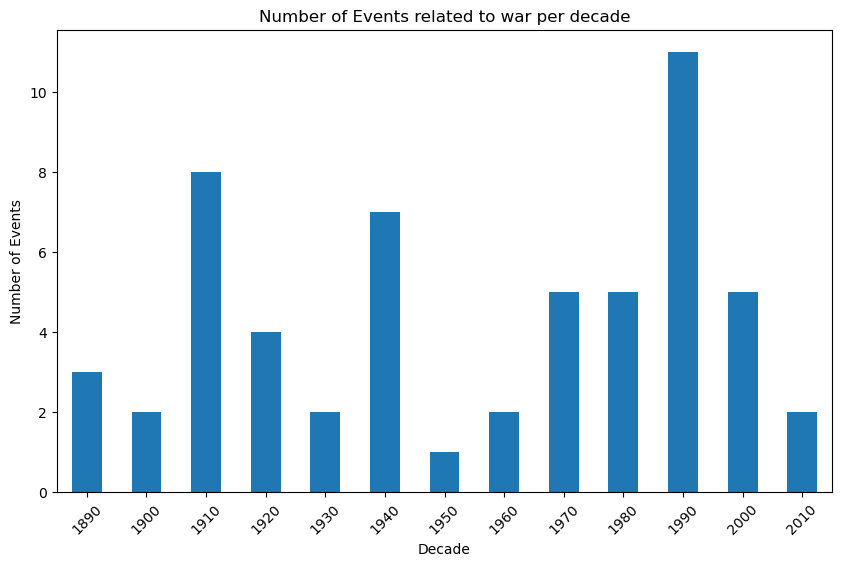

In [68]:
#Plot the number of war per decade
# Extract the year from the 'Year' column and convert it to an integer
df_war['date'] = df_war['date'].astype(int)

# Create a new column for the decade
df_war['Decade'] = (df_war['date'] // 10) * 10

# Group the data by decade and count the number of events
decade_counts = df_war.groupby('Decade').size()

# Plot the data
plt.figure(figsize=(10, 6))
decade_counts.plot(kind='bar')
plt.xlabel('Decade')
plt.ylabel('Number of Events')
plt.title('Number of Events related to war per decade')
plt.xticks(rotation=45)
plt.show()

In [69]:
# Extract Continents
# Function country_to_continent from https://stackoverflow.com/questions/55910004/get-continent-name-from-country-using-pycountry
# Function find_countries from https://fastdatascience.com/natural-language-processing/country-named-entity-recognition/
import pycountry_convert as pc
import pycountry
from country_named_entity_recognition import find_countries
import pandas as pd


# Fallback keyword-based continent mapping for ambiguous cases
keyword_continent_mapping = {
    "Balkan": "Europe",
    "Congo": "Africa",
    "Liberian": "Africa",
    "Palestine": "Asia",
    "Soviet": "Europe",  # USSR context can be complex; usually in Europe
    "Chechen": "Asia",
    "Falklands": "South America",
    "Somali": "Africa",
    "Yemen": "Asia",
    "Nepal": "Asia",
    "Rwandan": "Africa",
    "Kurdish": "Asia",
    "Peruvian": "South America",
    "Cuban": "North America",
    "Dominican": "North America",
    "Ukrainian": "Europe",
    "Finnish": "Europe",
    "Austrian": "Europe",
    "Estonian": "Europe",
    "Irish": "Europe",
    "Turkish": "Asia",
    "Nicaraguan": "North America",
    "Austrialian": "Australia",
    "Spanish": "Europe",
    "Chinese": "Asia",
    "Paraguayan": "South America",
    "Costa Rican": "North America",
    "Algerian": "Africa",
    "Chadian": "Africa",
    "Nigerian": "Africa",
    "Ethiopian": "Africa",
    "Eritrean": "Africa",
    "Angolan": "Africa",
    "Rhodesian": "Africa",
    "Ugandan": "Africa",
    "Sri Lankan": "Asia",
    "Georgian": "North America",
    "Algerian": "Africa",
    "Salvadoran": "North America",
    "Mozambican": "Africa",
    "Tajikistani": "Asia",
    "Bissau-Guinean": "Africa",
    "Sudanese": "Africa",
    "Iraqi": "Asia",
    "World War": "World",
    "Cold War": "World",
    "Thousand Days'": "South America",
    "Herero": "Africa",
    "National Protection": "Asia",
    "Central Plains": "Asia",
    "Dirty": "North America",

    # Add more specific keywords as needed
}

def country_to_continent(country_name):
    # Normalize country names using alternative names dictionary
    #country_name = alternative_names.get(country_name, country_name)  # Replace with alternative name if available
    try:
        # Use pycountry to lookup alpha2 code, then map to continent
        country = pycountry.countries.lookup(country_name)
        country_alpha2 = country.alpha_2
        country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        country_continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
        return country_continent_name
    except LookupError:
        print(f"Country not found: {country_name}")
        return None
    except Exception as e:
        print(f"Error converting country to continent: {country_name}, {e}")
        return None

# Main processing loop to detect and assign continents
for index, row in df_war.iterrows():
    # Step 1: Try extracting countries from the 'label' using find_countries
    countries = find_countries(row['label'])
    country_names = [country[0].name for country in countries]  # Extract the country names
    
    # Step 2: Initialize a list to gather identified continents
    continents = []
    
    # Step 3: Process each identified country
    for country in country_names:
        continent = country_to_continent(country)
        if continent:
            continents.append(continent)
    
    # Step 4: Fallback to keyword mapping if no countries were found
    if not continents:
        for keyword, continent in keyword_continent_mapping.items():
            if keyword.lower() in row['label'].lower():
                continents.append(continent)
                break  # Stop after the first match
    
    # Step 5: Assign continent to DataFrame, use 'Unknown' if still empty
    if continents:
        df_war.loc[index, 'Continent'] = continents[0]  # Choose the first matched continent
    else:
        df_war.loc[index, 'Continent'] = 'Unknown'
        print(f"No continent found for event: {row['label']}")

# Save the updated DataFrame to a new CSV file
df_war.to_csv('war_events_continent.csv', index=False)


/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_29223/2582583510.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_war.loc[index, 'Continent'] = continents[0]  # Choose the first matched continent


/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_29223/380550755.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=decade_continent_counts, x='Decade', y='Count', hue='Continent', ci=None, palette=color_palette)


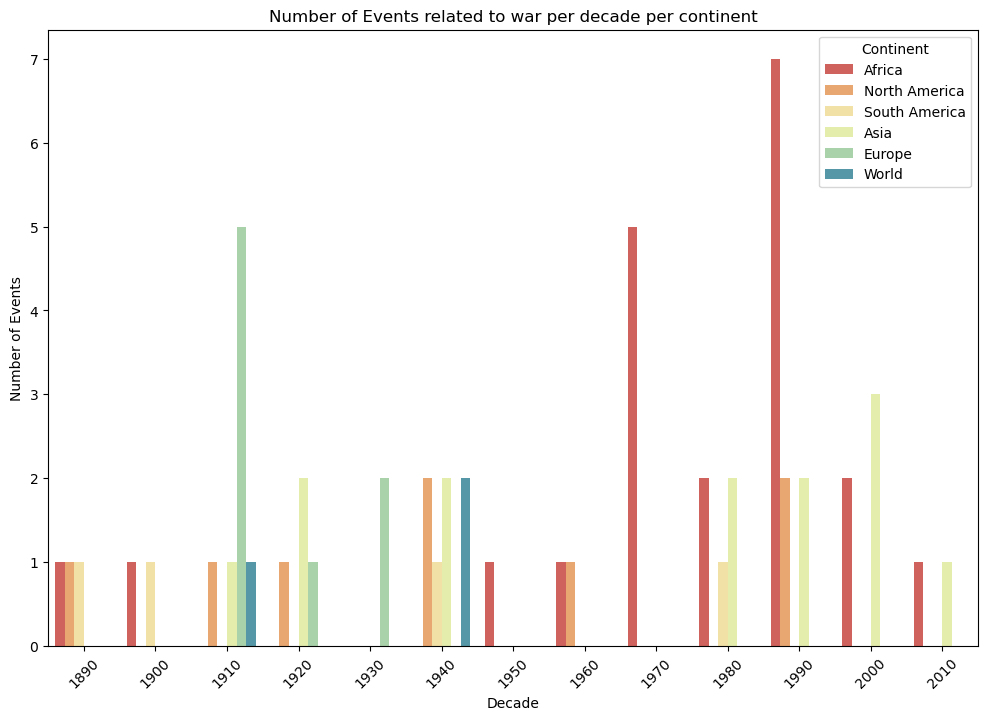

In [70]:
# Group the data by decade and continent and count the number of events
decade_continent_counts = df_war.groupby(['Decade', 'Continent']).size().reset_index(name='Count')

color_palette =sns.color_palette("Spectral")
# Plot the data using Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(data=decade_continent_counts, x='Decade', y='Count', hue='Continent', ci=None, palette=color_palette)

# Customize the plot
plt.xlabel('Decade')
plt.ylabel('Number of Events')
plt.title('Number of Events related to war per decade per continent')
plt.xticks(rotation=45)
plt.legend(title='Continent')
plt.show()

> Natural events